# National Parks Service #

You will perform some data analysis on the conservation statuses of these species and investigate if there are any patterns or themes to the types of species that become endangered. During this project, you will analyze, clean up, and plot data as well as pose questions and seek to answer them in a meaningful way.

> All imports will appear in the following section for ease of adding to at a later date:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

## Load the data ##
first of all I will read the csv files into a pandas DataFrame:

In [2]:
observations = pd.read_csv('observations.csv')
species_info = pd.read_csv('species_info.csv')

Then view the first 5 rows of each DataFrame

In [3]:
print(observations.head())


            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85


In [4]:
print(species_info.head())

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  


## Understanding the Data ##
Further exploration with info(), columns, nunique, and describe()

In [5]:
print(observations.columns)
print(observations.info())

Index(['scientific_name', 'park_name', 'observations'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None


the observations set appears to be clean with 23295 entries. I suspect that some of the scientific names will compare across both data sets. I will explore this at aa later date and maybe look to combine some of the data into a new dataset.

In [6]:
print(species_info.columns)
print(species_info.info())

Index(['category', 'scientific_name', 'common_names', 'conservation_status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None


This data set has 5824 rows. conservation status appears to have a lot of null values: I will need to check the percentage of this column being NAN to see if it meets the 60% missing criteria to delete this column entirely. this would mean that I would not be able to look specifically at the conversation status of all species, I may be restricted at looking at a subset of the data.

Let's look at how many unique scientific names we have in each data set:

In [7]:
print(f'observations: {observations.scientific_name.nunique()}')
print(f'species_info: {species_info.scientific_name.nunique()}')


observations: 5541
species_info: 5541


This looks promising there is exactly the same number of unique scientific names in the data set. I just need to remember how to compare these across two data sets to see if they have the same unique scientific names. However species_info has more entries than there are unique scientific names; as I found out by running the data in 'jedijoff' branch there is some duplication of the common names which occurs in this data set, so I need to clean it at this point:

In [8]:
# copy the unique values into a variable for later use:
unique_scientific_observations = observations.scientific_name.unique()
unique_scientific_species = species_info.scientific_name.unique()

# dropping duplicated scientific names to clean the common names.
species_info.drop_duplicates(subset='scientific_name', inplace=True)
species_info.info # This shows that this data set is now only contains unique scientific names

<bound method DataFrame.info of             category                scientific_name  \
0             Mammal  Clethrionomys gapperi gapperi   
1             Mammal                      Bos bison   
2             Mammal                     Bos taurus   
3             Mammal                     Ovis aries   
4             Mammal                 Cervus elaphus   
...              ...                            ...   
5819  Vascular Plant               Solanum parishii   
5820  Vascular Plant                  Solanum xanti   
5821  Vascular Plant         Parthenocissus vitacea   
5822  Vascular Plant              Vitis californica   
5823  Vascular Plant            Tribulus terrestris   

                                           common_names conservation_status  
0                              Gapper's Red-Backed Vole                 NaN  
1                                 American Bison, Bison                 NaN  
2     Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 N

In [9]:
unique_scientific_observations.sort
unique_scientific_species.sort

print(unique_scientific_observations)
print(unique_scientific_species)

['Vicia benghalensis' 'Neovison vison' 'Prunus subcordata' ...
 'Ranunculus hebecarpus' 'Gulo gulo' 'Dichanthelium depauperatum']
['Clethrionomys gapperi gapperi' 'Bos bison' 'Bos taurus' ...
 'Parthenocissus vitacea' 'Vitis californica' 'Tribulus terrestris']


From this observation it does not appear that these 2 lists may have the same unique values for 'scientific_name', if this is the case I may be able to clean some of the missing data. I need to check if the unique names from both data sets are equal:

In [10]:
same_scientific = []
for observation in unique_scientific_observations:
    if observation in unique_scientific_species:
        same_scientific.append(observation) # if same_scientific is the same length as unique_scientific_observations, they have the same values

print(len(same_scientific) == len(unique_scientific_observations))

True


From this check I can now confirm that both data sets have exactly the same number of unique scientific names. The only column I am concerned about is the conservation_status column in the 'species_info' data set so I will look at the unique values there next:

In [11]:
unique_conservation_status = species_info.conservation_status.unique()
unique_conservation_status

array([nan, 'Species of Concern', 'Endangered', 'Threatened',
       'In Recovery'], dtype=object)

From these catergories it appears these are only NaN, when the species is considered at risk of becomming extinct, I think it would be ok to consider the other values as 'no concern', which would complete the data set and make it more viable for running computations on. I will therefore replace all NAN values with 'no concern' to make the data set cleaner.

In [12]:
species_info = species_info.fillna(value={'conservation_status': 'no concern'})
print(species_info.head())
print(species_info.info()) # Check that all values have an entry

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole          no concern  
1                              American Bison, Bison          no concern  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          no concern  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)          no concern  
4                                      Wapiti Or Elk          no concern  
<class 'pandas.core.frame.DataFrame'>
Index: 5541 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5541 non-null   object
 1   scientific_name      5541 

The next data I need to look at is the parks data. I need to understand how many parks there are, in the observations dataset and what their names are:

In [13]:
print(observations.head())
print(observations.park_name.nunique())
print(observations.park_name.unique())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
4
['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


The next lcolumn to investigate is the 'category' column in the species data set:

In [14]:
print(species_info.head())
print(species_info.category.nunique())
print(species_info.category.unique())

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole          no concern  
1                              American Bison, Bison          no concern  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          no concern  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)          no concern  
4                                      Wapiti Or Elk          no concern  
7
['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']


The last column to investigate in observations data set is the 'observations' column. I will now sum the total number of observations:


In [15]:
total_observations = np.sum([observations.observations])
print(f'Total number of observations: {total_observations}')

Total number of observations: 3314739


The 'common_names' column has lists as its values, this ought to be trimmed down to just one name per category. I shall go with the first name in each list:


In [16]:
li = species_info.common_names
res = reduce(lambda x, y: x + "_" + y, li)
print(species_info.head())
      

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole          no concern  
1                              American Bison, Bison          no concern  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          no concern  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)          no concern  
4                                      Wapiti Or Elk          no concern  


## Summary of Data ##

Observations has the following columns: scientific_name, park_name and observations.
Species info has the following columns: category, scientific_name, common_names,  and conservation_status.

The column scientific status in both sets of data have the same unique values. and so could be used to merge the data sets into one larger data set for analysis. 

There has been a total of 3,314,739 observations of the species across 4 parks: Great Smoky Mountains National Park, Yosemite National Park, Bryce National Park, and Yellowstone National Park. 

The category column in species_info has 7 categories: Mammal, Bird, Reptile, Amphibian, Fish, Vascular Plant, and Nonvascular Plant.

The column 'conservation_status' in species  now has 5 categories: 'no concern', 'Species of Concern', 'Endangered', 'Threatened', and 'In Recovery'


## Merging the datasets ##
I think it would be helpful to merge the species info into the observations data set to make one data set, before running analysis on the datasets. I'm going to attempt a merge:

In [17]:
new_observations = pd.merge(observations,
                            species_info,
                            left_on='scientific_name',
                            right_on='scientific_name'
                           )

print(new_observations.head())

            scientific_name                            park_name  \
0        Vicia benghalensis  Great Smoky Mountains National Park   
1            Neovison vison  Great Smoky Mountains National Park   
2         Prunus subcordata               Yosemite National Park   
3      Abutilon theophrasti                  Bryce National Park   
4  Githopsis specularioides  Great Smoky Mountains National Park   

   observations        category                        common_names  \
0            68  Vascular Plant  Purple Vetch, Reddish Tufted Vetch   
1            77          Mammal                       American Mink   
2           138  Vascular Plant                        Klamath Plum   
3            84  Vascular Plant                          Velvetleaf   
4            85  Vascular Plant                      Common Bluecup   

  conservation_status  
0          no concern  
1          no concern  
2          no concern  
3          no concern  
4          no concern  


## Analasis of the data ##

I am going to look at category vs observations in a series of box plots to see if there is an immediate concern showing here: 

<function matplotlib.pyplot.clf() -> 'None'>

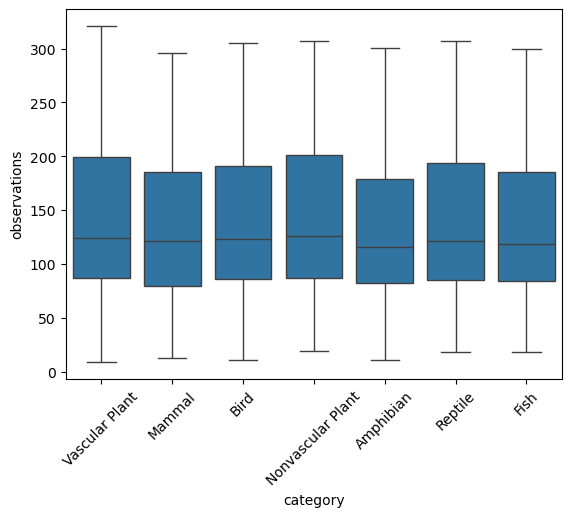

In [18]:
ax = sns.boxplot(data=new_observations, x='category', y='observations')
ax.tick_params(axis='x', labelrotation=45)
plt.show
plt.clf

It appears there are similar numbers of observations across each category. I shall now start digging deep into each category

### We were tasked with finding patterns in those species that are endangered ###
I am going to look at the data within conservation status and plot boxplot of 'conservation status' against the number of observations.

<function matplotlib.pyplot.clf() -> 'None'>

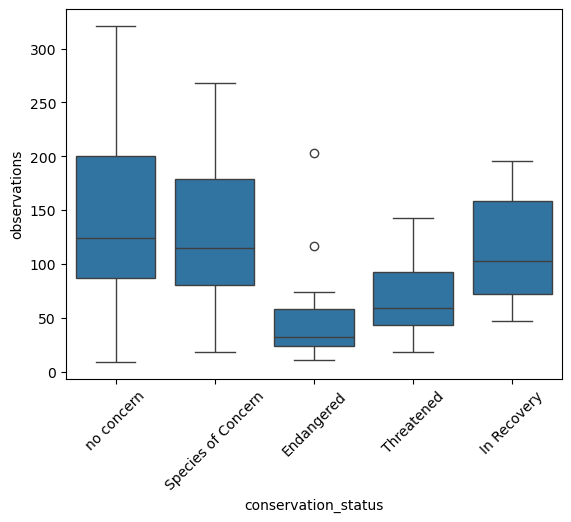

In [19]:
ax = sns.boxplot(data=new_observations, x='conservation_status', y='observations')
ax.tick_params(axis='x', labelrotation=45)
plt.show
plt.clf

Barring outliers it does appear that species that are labeled 'Endangered' have a significantly lower mean of observations than any other conservation status. The total range of the observations is significantly lower than other categories indicating there may be a correlation between observations and conservation status. The in recovery data indicates that with support species can recover.I will dig deeper into the endangered species to see which species appear to be least observed:

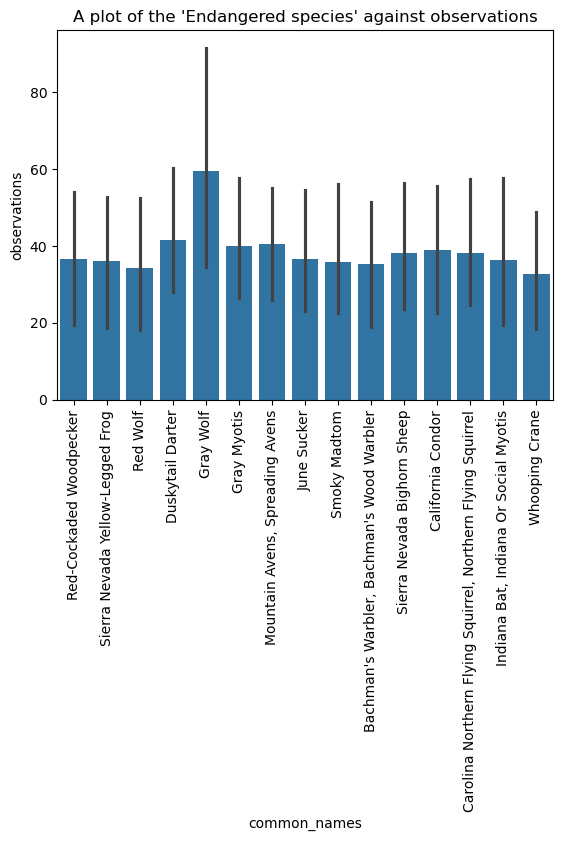

<Figure size 640x480 with 0 Axes>

In [20]:
endangered = new_observations[new_observations['conservation_status'] == 'Endangered']
ax = sns.barplot(data=new_observations, x=endangered.common_names, y='observations')
ax.tick_params(axis='x', labelrotation=90)
plt.title('A plot of the \'Endangered species\' against observations')
plt.show()
plt.clf()

# And now the species_info dataset has been cleared of duplicates the graph below only shows one 'Gray Wolf' bar.

Looking at this graph the Gray wolf appears in the data twice, so it appears there is some duplication of the data. I think I may need to drop duplicates of the scientific names to be certain that I am dropping the correct data (as the scientific names will only correlate to one species). I have to be careful though as there are 4 different parks and each one will have observations of the same species, which I want to retain, so I will iterate through the parks and drop duplicate data based on scientific name for each park.

In [21]:
parks = new_observations.park_name.unique()
parks

array(['Great Smoky Mountains National Park', 'Yosemite National Park',
       'Bryce National Park', 'Yellowstone National Park'], dtype=object)

In [22]:
slices = []
for park in parks:
    slice = new_observations[new_observations.park_name == park]
    # drop duplicates fron slice
    slice.drop_duplicates(subset='scientific_name')
    slices.append(slice)
new_observations = pd.concat(slices)
new_observations.head()  

,scientific_name,park_name,observations,category,common_names,conservation_status
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",no concern
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,no concern
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,no concern
7,Elymus multisetus,Great Smoky Mountains National Park,39,Vascular Plant,"Big Squirreltail, Big Wild Rye",no concern
14,Fabronia ciliaris,Great Smoky Mountains National Park,72,Nonvascular Plant,Fabronia Moss,no concern


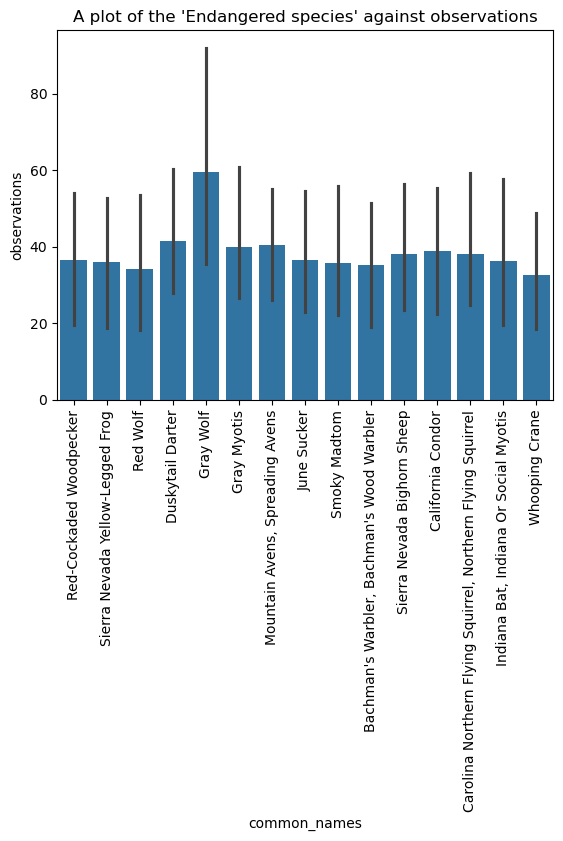

<Figure size 640x480 with 0 Axes>

In [23]:
# Rerun the previous plot and the Gray wolf should now only appear once.
ax = sns.barplot(data=new_observations, x=endangered.common_names, y='observations')
ax.tick_params(axis='x', labelrotation=90)
plt.title('A plot of the \'Endangered species\' against observations')
plt.show()
plt.clf()